# Projeto Final - Classificação da Qualidade de Vinhos Brancos com Regressão Logística e KNN

**Objetivo:** classificar vinhos brancos em três categorias de qualidade (`baixa`, `média` e `alta`) a partir de características físico-químicas.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Raiz do projeto:", PROJECT_ROOT)

Python: 3.13.5
Raiz do projeto: /mnt/data/Projeto_Wine_Quality_Revisado


## 1. Carregamento do conjunto de dados

É utilizado o arquivo de **vinhos brancos** do conjunto *Wine Quality*. Cada linha representa uma amostra de vinho e as colunas de entrada representam medições físico-químicas. A coluna `quality` contém a nota sensorial original.

In [2]:
df = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=";")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())

Dimensões: 4898 linhas x 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 2. Auditoria e Análise Exploratória de Dados (EDA)

Antes de modelar, verificamos tipos de dados, valores ausentes, duplicatas, estatísticas descritivas, distribuição da qualidade e possíveis outliers pelo critério do intervalo interquartil (IQR).

In [3]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "valores_unicos": df.nunique()
})
print("Valores ausentes no dataset:", int(df.isna().sum().sum()))
print("Linhas duplicadas:", int(df.duplicated().sum()))
display(audit)
display(df.describe().T)
audit.to_csv(OUTPUT_DIR / "auditoria_colunas.csv")
df.describe().T.to_csv(OUTPUT_DIR / "estatisticas_descritivas.csv")

Valores ausentes no dataset: 0
Linhas duplicadas: 937


,tipo,ausentes,valores_unicos
fixed acidity,float64,0,68
volatile acidity,float64,0,125
citric acid,float64,0,87
residual sugar,float64,0,310
chlorides,float64,0,160
free sulfur dioxide,float64,0,132
total sulfur dioxide,float64,0,251
density,float64,0,890
pH,float64,0,103
sulphates,float64,0,79


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [4]:
# Contagem de possíveis outliers pelo critério IQR (apenas diagnóstico)
outlier_rows = []
for col in df.drop(columns=["quality"]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    count = int(((df[col] < low) | (df[col] > high)).sum())
    outlier_rows.append({"variavel": col, "outliers_iqr": count})

outliers = pd.DataFrame(outlier_rows)
display(outliers)
outliers.to_csv(OUTPUT_DIR / "outliers_iqr.csv", index=False)

,variavel,outliers_iqr
0,fixed acidity,119
1,volatile acidity,186
2,citric acid,270
3,residual sugar,7
4,chlorides,208
5,free sulfur dioxide,50
6,total sulfur dioxide,19
7,density,5
8,pH,75
9,sulphates,124


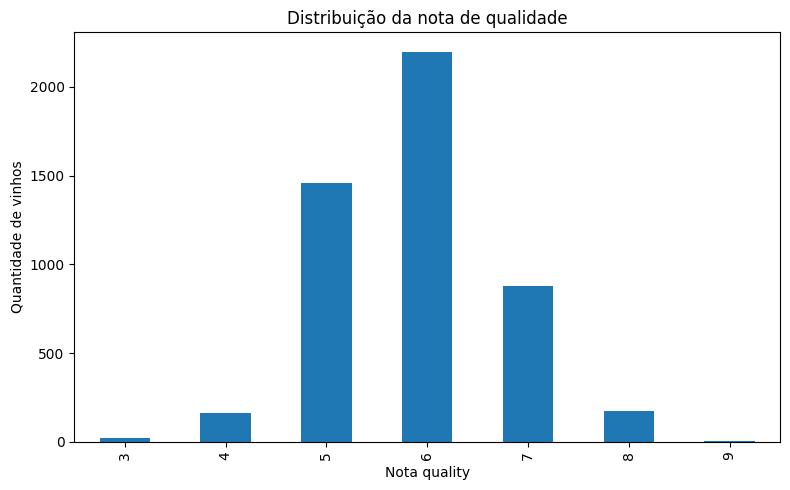

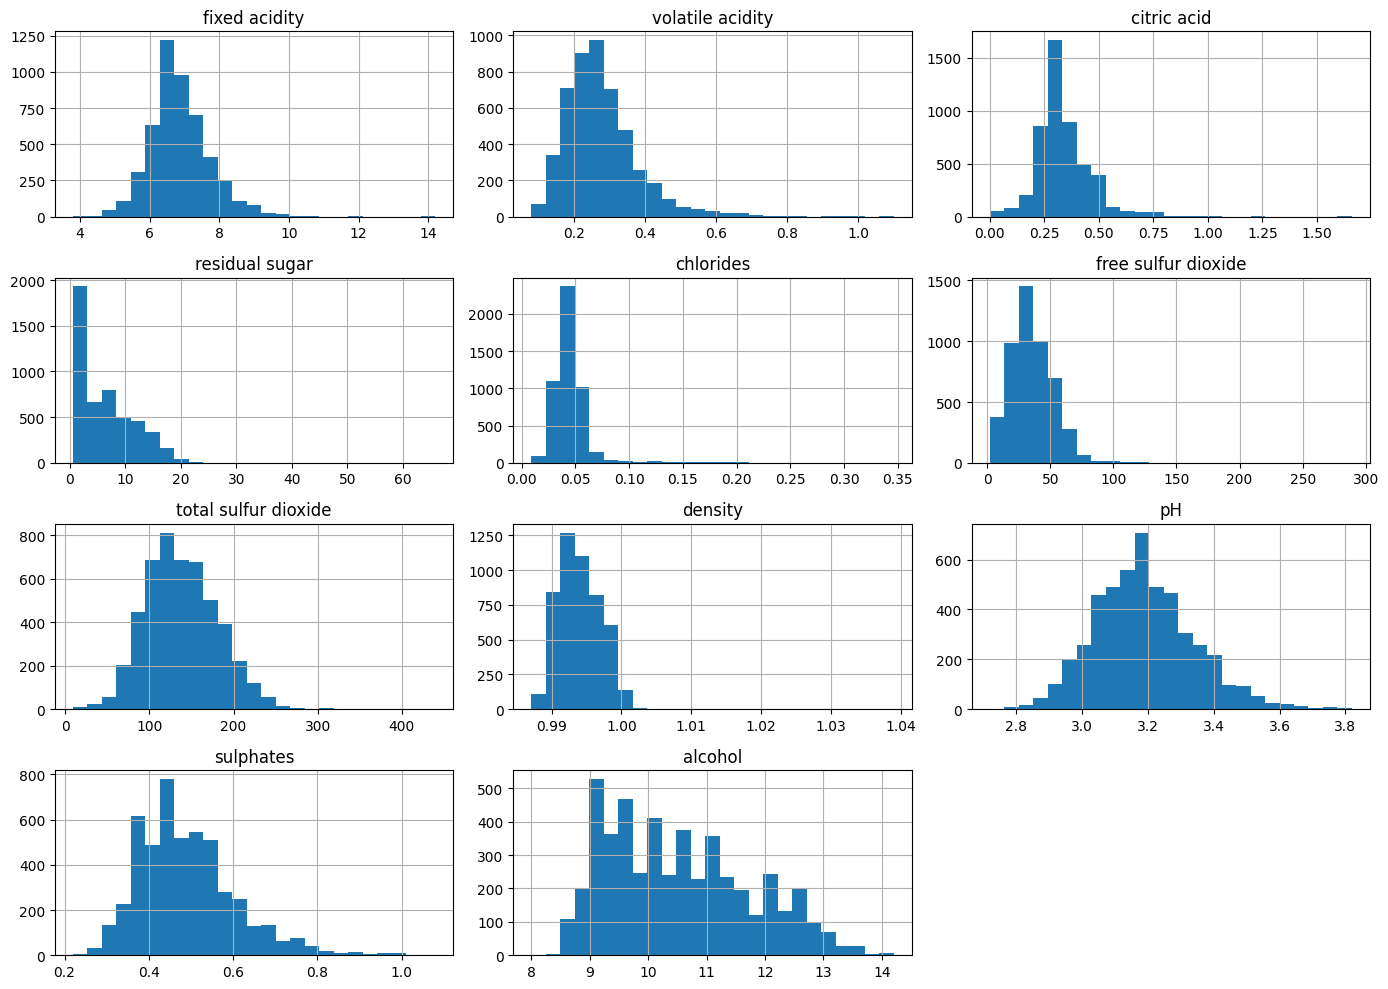

In [5]:
plt.figure(figsize=(8, 5))
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da nota de qualidade")
plt.xlabel("Nota quality")
plt.ylabel("Quantidade de vinhos")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribuicao_quality.png", dpi=160)
plt.show()

# Histogramas das variáveis de entrada
df.drop(columns=["quality"]).hist(figsize=(14, 10), bins=25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histogramas_variaveis.png", dpi=160)
plt.show()

## 3. Preparação da variável alvo

Para tornar o problema uma **classificação multiclasse**, a nota original é agrupada em três categorias:

- `baixa`: nota até 4;
- `média`: notas 5 e 6;
- `alta`: nota 7 ou maior.

As duplicatas exatas são removidas antes da divisão dos dados para evitar que a mesma observação apareça simultaneamente em treino e teste.

In [6]:
model_df = df.drop_duplicates().reset_index(drop=True)
model_df["quality_class"] = pd.cut(
    model_df["quality"],
    bins=[-np.inf, 4, 6, np.inf],
    labels=["baixa", "média", "alta"]
)

X = model_df.drop(columns=["quality", "quality_class"])
y = model_df["quality_class"]

class_distribution = pd.DataFrame({
    "quantidade": y.value_counts().sort_index(),
    "percentual": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})
print(f"Registros após remover duplicatas: {len(model_df)}")
display(class_distribution)
class_distribution.to_csv(OUTPUT_DIR / "distribuicao_classes.csv")

Registros após remover duplicatas: 3961


,quantidade,percentual
quality_class,,
baixa,173,4.37
média,2963,74.80
alta,825,20.83


## 4. Divisão treino/teste

Seguindo a orientação das aulas para bases de tamanho pequeno/médio, reservamos **20% para teste** e usamos **validação cruzada (5-fold)** somente dentro dos 80% de treino. A divisão é estratificada para preservar a proporção das classes.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Treino:", X_train.shape, "Teste:", X_test.shape)

Treino: (3168, 11) Teste: (793, 11)


## 5. Pré-processamento com Pipeline

Os atributos são numéricos, portanto não é necessário *encoding* categórico. O `Pipeline` aplica:

1. `SimpleImputer(strategy="median")` para lidar com eventuais valores ausentes;
2. `StandardScaler()` para colocar as variáveis em escalas comparáveis;
3. o classificador escolhido.

A mediana e a escala são aprendidas apenas com os dados de treino, evitando vazamento de dados.

In [8]:
def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 6. Modelo A - Regressão Logística

A Regressão Logística é um algoritmo de **classificação** que estima probabilidades para as classes. Como visto em aula, comparamos valores simples do hiperparâmetro `C` e selecionamos a configuração com maior F1 macro médio na validação cruzada.

In [9]:
logistic_results = []
for C in [0.1, 1, 10]:
    model = make_pipeline(LogisticRegression(C=C, max_iter=2000))
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    logistic_results.append({"C": C, "f1_macro_cv": scores.mean(), "desvio": scores.std()})

logistic_cv = pd.DataFrame(logistic_results)
best_C = float(logistic_cv.loc[logistic_cv["f1_macro_cv"].idxmax(), "C"])
display(logistic_cv.round(4))
print("Melhor C:", best_C)
logistic_cv.to_csv(OUTPUT_DIR / "validacao_regressao_logistica.csv", index=False)

,C,f1_macro_cv,desvio
0,0.1,0.4589,0.0206
1,1.0,0.4651,0.0222
2,10.0,0.4643,0.0223


Melhor C: 1.0


## 7. Modelo B - KNN

O KNN classifica uma nova amostra observando as classes dos vizinhos mais próximos. Conforme apresentado em aula, não existe um valor de `K` universal; por isso são testados valores ímpares simples.

In [10]:
knn_results = []
for k in [3, 5, 7, 9, 11]:
    model = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    knn_results.append({"k": k, "f1_macro_cv": scores.mean(), "desvio": scores.std()})

knn_cv = pd.DataFrame(knn_results)
best_k = int(knn_cv.loc[knn_cv["f1_macro_cv"].idxmax(), "k"])
display(knn_cv.round(4))
print("Melhor k:", best_k)
knn_cv.to_csv(OUTPUT_DIR / "validacao_knn.csv", index=False)

,k,f1_macro_cv,desvio
0,3,0.4917,0.0120
1,5,0.4709,0.0145
2,7,0.4503,0.0133
3,9,0.4530,0.0196
4,11,0.4499,0.0096


Melhor k: 3


## 8. Avaliação final no conjunto de teste

Também usamos um `DummyClassifier` como referência simples. Ele não é um modelo candidato final; serve apenas para verificar se os modelos aprendidos superam a estratégia de sempre prever a classe mais frequente.

In [11]:
models = {
    "DummyClassifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "Regressão Logística": make_pipeline(LogisticRegression(C=best_C, max_iter=2000)),
    "KNN": make_pipeline(KNeighborsClassifier(n_neighbors=best_k))
}

rows = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    rows.append({
        "modelo": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
    })
    pd.DataFrame(classification_report(y_test, pred, output_dict=True, zero_division=0)).T.to_csv(
        OUTPUT_DIR / f"relatorio_{name.lower().replace(' ', '_').replace('ã','a').replace('ç','c')}.csv"
    )

results = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results.round(4))
results.to_csv(OUTPUT_DIR / "metricas_teste.csv", index=False)

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,KNN,0.7730,0.6513,0.4985,0.5229
1,Regressão Logística,0.7718,0.6885,0.4363,0.4585
2,DummyClassifier,0.7478,0.2493,0.3333,0.2852


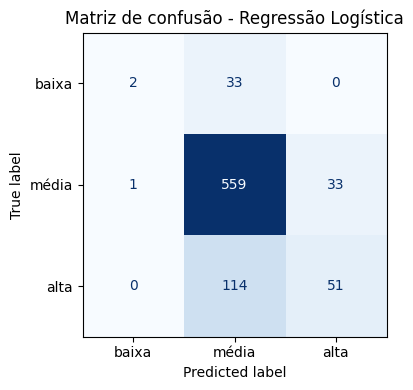

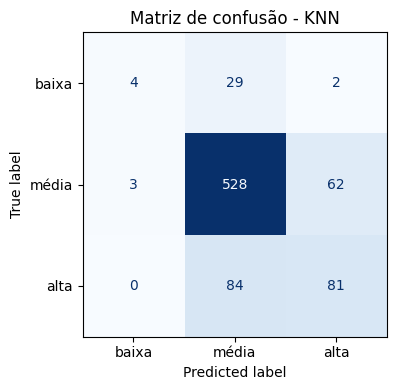

In [12]:
# Matrizes de confusão dos dois modelos principais
for name in ["Regressão Logística", "KNN"]:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name],
        labels=["baixa", "média", "alta"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(f"Matriz de confusão - {name}")
    plt.tight_layout()
    filename = "matriz_logistica.png" if name == "Regressão Logística" else "matriz_knn.png"
    plt.savefig(OUTPUT_DIR / filename, dpi=160)
    plt.show()

## 9. Conclusão

A comparação final considera principalmente o **F1 macro**, pois as classes são desbalanceadas e essa métrica evita avaliar o modelo apenas pela classe majoritária. `Accuracy`, `Precision` e `Recall` também são apresentados para complementar a análise.

Na execução de referência deste projeto, o **KNN** obteve o maior F1 macro no conjunto de teste entre os dois modelos candidatos, embora a Regressão Logística apresente maior simplicidade e interpretabilidade. A classe `baixa` continua sendo a mais difícil de reconhecer devido à pequena quantidade de exemplos disponíveis.